# Baseline Comparison: CNN vs LSTM vs BERT vs DistilBERT

This notebook trains four **text-only** baselines on the same Fakeddit split used
by the X-MAP notebook, so their scores are directly comparable to X-MAP's
multimodal (text+image) result.

**Consistency with the X-MAP notebook (`X_MAP_improved.ipynb`):**
- Same source file: `test_public.csv`
- Same subset size: `NUM_SAMPLES = 15000`
- Same split: 70% train / 10% val / 20% test, `random_state=42`, stratified on `2_way_label`
- Same label column: `2_way_label` (0 = Real, 1 = Fake)
- Same text field: `clean_title`

Baselines are text-only (no image branch) because CNN/LSTM/BERT/DistilBERT in the
fake-news-detection literature are almost always evaluated as text classifiers —
this also isolates how much the *image* branch is contributing in X-MAP versus a
same-architecture text encoder.

At the end, all four results are combined with X-MAP's already-measured test
numbers into one comparison table and chart.

### 1. Setup

In [1]:
!pip install -q transformers torch torchvision scikit-learn pandas matplotlib


In [2]:
import os
import re
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Device: cuda


### 2. Load data and reproduce X-MAP's duplicate-aware split

Same file, same `NUM_SAMPLES`, same `random_state` for the initial stratified subset as the X-MAP notebook. The train/val/test split itself reproduces X-MAP's **duplicate-aware, group-wise re-split** (Section 3.1.4 of the paper) -- not the original 70/10/20 random split -- since that is the split the final X-MAP model was retrained and reported on. Using the original random split here would put these baselines on different posts than X-MAP's headline results, making Table IV an apples-to-oranges comparison again.

In [3]:
df = pd.read_csv("test_public.csv")
print(df.shape)

NUM_SAMPLES = 15000

# Build the same 15,000-post stratified subset X-MAP uses (identical
# random_state=SEED), so the two notebooks start from the same posts.
subset_df, _ = train_test_split(
    df,
    train_size=NUM_SAMPLES,
    random_state=SEED,
    stratify=df["2_way_label"]
)
subset_df = subset_df.reset_index(drop=True)

# ------------------------------------------------------------------
# Reproduce X-MAP's duplicate-aware, group-wise re-split exactly
# (same logic as the "Group-wise, duplicate-aware re-split" cell in
# the main X-MAP notebook: cluster posts by exact/normalized title
# match, shared image_url, or near-duplicate title (TF-IDF cosine
# >= 0.90), then split with StratifiedGroupKFold so no cluster
# crosses a train/val/test boundary). Using the *original* random
# 70/10/20 split here would put these baselines on different posts
# than the final X-MAP model, invalidating the "same split" claim.
# ------------------------------------------------------------------
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedGroupKFold


def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


n = len(subset_df)
subset_df["norm_title"] = subset_df["clean_title"].apply(normalize_text)

parent = list(range(n))


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[ry] = rx


# a) exact/normalized title match
title_groups = defaultdict(list)
for i, t in enumerate(subset_df["norm_title"]):
    title_groups[t].append(i)
for idxs in title_groups.values():
    for j in idxs[1:]:
        union(idxs[0], j)

# b) shared image_url
url_groups = defaultdict(list)
for i, u in enumerate(subset_df["image_url"]):
    if pd.notna(u):
        url_groups[u].append(i)
for idxs in url_groups.values():
    for j in idxs[1:]:
        union(idxs[0], j)

# c) near-duplicate title (TF-IDF cosine >= 0.90), chunked to bound memory
vectorizer_full = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
tfidf_full = vectorizer_full.fit_transform(subset_df["norm_title"])

CHUNK = 1000
SIM_THRESHOLD = 0.9
for start in range(0, n, CHUNK):
    end = min(start + CHUNK, n)
    sim_chunk = (tfidf_full[start:end] @ tfidf_full[start:].T).toarray()
    for local_i in range(end - start):
        i = start + local_i
        row = sim_chunk[local_i]
        matches = np.where(row >= SIM_THRESHOLD)[0] + start
        for j in matches:
            if j > i:
                union(i, j)

subset_df["dup_cluster"] = [find(i) for i in range(n)]

n_clusters = subset_df["dup_cluster"].nunique()
print(f"{n} posts collapse into {n_clusters} duplicate-aware clusters "
      f"({n - n_clusters} posts merged into an existing cluster).")

labels = subset_df["2_way_label"].values
groups = subset_df["dup_cluster"].values

sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(sgkf_test.split(subset_df, labels, groups))

trainval_df = subset_df.iloc[trainval_idx].reset_index(drop=True)
test_df = subset_df.iloc[test_idx].reset_index(drop=True)

sgkf_val = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=SEED)
tv_labels = trainval_df["2_way_label"].values
tv_groups = trainval_df["dup_cluster"].values
train_idx, val_idx = next(sgkf_val.split(trainval_df, tv_labels, tv_groups))

train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

# Sanity check: this MUST match X-MAP's reported split sizes exactly
# (10,624 / 1,476 / 2,900). If it doesn't, something about subset_df
# or the clustering diverged from the main notebook and the "same
# split" claim no longer holds -- stop and investigate before training
# any baseline.
train_clusters = set(train_df["dup_cluster"])
val_clusters = set(val_df["dup_cluster"])
test_clusters = set(test_df["dup_cluster"])

print("Train:", len(train_df), train_df["2_way_label"].value_counts(normalize=True).to_dict())
print("Val  :", len(val_df), val_df["2_way_label"].value_counts(normalize=True).to_dict())
print("Test :", len(test_df), test_df["2_way_label"].value_counts(normalize=True).to_dict())
print("Cluster overlap (must all be 0):",
      "train n val =", len(train_clusters & val_clusters),
      "| train n test =", len(train_clusters & test_clusters),
      "| val n test =", len(val_clusters & test_clusters))

EXPECTED_SIZES = (10624, 1476, 2900)
actual_sizes = (len(train_df), len(val_df), len(test_df))
if actual_sizes != EXPECTED_SIZES:
    print(f"\n*** WARNING: split sizes {actual_sizes} do not match X-MAP's "
          f"reported {EXPECTED_SIZES}. Do not treat this as the same split "
          f"as the main notebook until this is resolved. ***")
else:
    print("\nSplit sizes match X-MAP's reported duplicate-aware split exactly.")

# Basic cleanup: drop rows with missing/empty titles
for d in (train_df, val_df, test_df):
    d["clean_title"] = d["clean_title"].fillna("").astype(str)


(59319, 16)
15000 posts collapse into 14085 duplicate-aware clusters (915 posts merged into an existing cluster).
Train: 10624 {0: 0.6057040662650602, 1: 0.39429593373493976}
Val  : 1476 {0: 0.6077235772357723, 1: 0.39227642276422764}
Test : 2900 {0: 0.5944827586206897, 1: 0.40551724137931033}
Cluster overlap (must all be 0): train n val = 0 | train n test = 0 | val n test = 0

Split sizes match X-MAP's reported duplicate-aware split exactly.


In [4]:
# Class weights (same rationale as X-MAP: imbalanced ~60/40 split)
class_counts = train_df["2_way_label"].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (len(class_counts) * c) for c in class_counts],
    dtype=torch.float
).to(device)
print("Class weights:", class_weights)


Class weights: tensor([0.8255, 1.2681], device='cuda:0')


### 3. Vocabulary + tokenizer for CNN / LSTM

CNN and LSTM use a simple whitespace/word-level vocabulary built from the training split only (no leakage from val/test). BERT and DistilBERT use their own pretrained subword tokenizers instead.

In [5]:
from collections import Counter

MAX_VOCAB_SIZE = 20000
MAX_LEN = 48

token_pattern = re.compile(r"[A-Za-z']+")

def simple_tokenize(text):
    return token_pattern.findall(text.lower())

counter = Counter()
for text in train_df["clean_title"]:
    counter.update(simple_tokenize(text))

# Reserve 0 = <pad>, 1 = <unk>
most_common = counter.most_common(MAX_VOCAB_SIZE - 2)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print("Vocab size:", VOCAB_SIZE)

def encode_text(text, vocab=vocab, max_len=MAX_LEN):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens[:max_len]]
    if len(ids) < max_len:
        ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
    return ids


Vocab size: 14703


### 4. Datasets

In [6]:
class VocabTextDataset(Dataset):
    """Word-index dataset for the CNN and LSTM baselines."""

    def __init__(self, dataframe):
        self.texts = dataframe["clean_title"].tolist()
        self.labels = dataframe["2_way_label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx])
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }


class TransformerTextDataset(Dataset):
    """Subword-tokenized dataset for the BERT / DistilBERT baselines."""

    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe["clean_title"].tolist()
        self.labels = dataframe["2_way_label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }


### 5. Model definitions

In [7]:
class TextCNN(nn.Module):
    """Kim (2014)-style CNN text classifier."""

    def __init__(self, vocab_size, embed_dim=128, num_filters=100,
                 filter_sizes=(3, 4, 5), num_classes=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)          # (B, L, E)
        x = x.transpose(1, 2)                   # (B, E, L)
        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(x))             # (B, F, L')
            pooled = torch.max(c, dim=2).values  # (B, F)
            conv_outs.append(pooled)
        features = torch.cat(conv_outs, dim=1)
        features = self.dropout(features)
        return self.fc(features)


class TextLSTM(nn.Module):
    """Bidirectional LSTM text classifier."""

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, num_classes=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)                # (B, L, E)
        _, (h_n, _) = self.lstm(x)                    # h_n: (num_layers*2, B, H)
        # Concatenate the final forward and backward hidden states
        h_forward = h_n[-2, :, :]
        h_backward = h_n[-1, :, :]
        h = torch.cat([h_forward, h_backward], dim=1)  # (B, 2H)
        h = self.dropout(h)
        return self.fc(h)


class TransformerClassifier(nn.Module):
    """Shared wrapper for BERT / DistilBERT: encoder + linear head on [CLS]."""

    def __init__(self, encoder, hidden_size, num_classes=2, dropout=0.3,
                 freeze_layers=0, layer_path=None):
        super().__init__()
        self.encoder = encoder

        # Optionally freeze the first N transformer layers, mirroring the
        # X-MAP notebook's approach for its DistilBERT branch (keeps
        # general language features intact when fine-tuning on a few
        # thousand examples).
        if freeze_layers > 0 and layer_path is not None:
            layers = layer_path(self.encoder)
            for layer in layers[:freeze_layers]:
                for p in layer.parameters():
                    p.requires_grad = False

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        return self.fc(cls)


### 6. Shared train / evaluate loop

In [8]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None,
              is_transformer=False):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch in loader:
            labels = batch["label"].to(device)

            if is_transformer:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                input_ids = batch["input_ids"].to(device)
                logits = model(input_ids)

            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1


def train_model(model, train_loader, val_loader, criterion, optimizer,
                 scheduler=None, num_epochs=3, patience=2, is_transformer=False,
                 ckpt_path="model_best.pth"):
    best_val_f1 = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss, train_acc, train_f1 = run_epoch(
            model, train_loader, criterion, optimizer, scheduler, is_transformer
        )
        val_loss, val_acc, val_f1 = run_epoch(
            model, val_loader, criterion, optimizer=None, is_transformer=is_transformer
        )

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> New best model saved ({ckpt_path})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  -> No improvement for {patience} epochs, stopping early.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model


def evaluate_model(model, loader, is_transformer=False, name=""):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            labels = batch["label"].to(device)
            if is_transformer:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                input_ids = batch["input_ids"].to(device)
                logits = model(input_ids)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = {
        "model": name,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
    }

    print(f"\n=== {name} — Test Set ===")
    for k in ("accuracy", "precision", "recall", "f1"):
        print(f"{k.capitalize():10s}: {metrics[k]:.4f}")
    print(classification_report(all_labels, all_preds))
    print(confusion_matrix(all_labels, all_preds))

    return metrics


### 7. Common training config

In [9]:
BATCH_SIZE = 16
NUM_EPOCHS = 3
criterion = nn.CrossEntropyLoss(weight=class_weights)

results = []  # collects metrics dicts from each baseline


## 8. Baseline 1 — CNN

In [10]:
cnn_train_loader = DataLoader(VocabTextDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
cnn_val_loader = DataLoader(VocabTextDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
cnn_test_loader = DataLoader(VocabTextDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

cnn_model = TextCNN(vocab_size=VOCAB_SIZE).to(device)
cnn_optimizer = AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=0.01)

cnn_model = train_model(
    cnn_model, cnn_train_loader, cnn_val_loader, criterion, cnn_optimizer,
    num_epochs=NUM_EPOCHS, is_transformer=False, ckpt_path="cnn_best.pth"
)


Epoch 1/3 | Train Loss: 0.6252 | Val Acc: 0.7615 | Val F1: 0.7067
  -> New best model saved (cnn_best.pth)
Epoch 2/3 | Train Loss: 0.4914 | Val Acc: 0.7622 | Val F1: 0.7139
  -> New best model saved (cnn_best.pth)
Epoch 3/3 | Train Loss: 0.3901 | Val Acc: 0.7554 | Val F1: 0.6797


In [11]:
cnn_metrics = evaluate_model(cnn_model, cnn_test_loader, is_transformer=False, name="CNN")
results.append(cnn_metrics)



=== CNN — Test Set ===
Accuracy  : 0.7431
Precision : 0.6662
Recall    : 0.7347
F1        : 0.6987
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      1724
           1       0.67      0.73      0.70      1176

    accuracy                           0.74      2900
   macro avg       0.74      0.74      0.74      2900
weighted avg       0.75      0.74      0.74      2900

[[1291  433]
 [ 312  864]]


## 9. Baseline 2 — LSTM

In [12]:
lstm_train_loader = DataLoader(VocabTextDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
lstm_val_loader = DataLoader(VocabTextDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
lstm_test_loader = DataLoader(VocabTextDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

lstm_model = TextLSTM(vocab_size=VOCAB_SIZE).to(device)
lstm_optimizer = AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=0.01)

lstm_model = train_model(
    lstm_model, lstm_train_loader, lstm_val_loader, criterion, lstm_optimizer,
    num_epochs=NUM_EPOCHS, is_transformer=False, ckpt_path="lstm_best.pth"
)


Epoch 1/3 | Train Loss: 0.5546 | Val Acc: 0.7629 | Val F1: 0.7340
  -> New best model saved (lstm_best.pth)
Epoch 2/3 | Train Loss: 0.4235 | Val Acc: 0.7764 | Val F1: 0.7189
Epoch 3/3 | Train Loss: 0.2856 | Val Acc: 0.7615 | Val F1: 0.7134
  -> No improvement for 2 epochs, stopping early.


In [13]:
lstm_metrics = evaluate_model(lstm_model, lstm_test_loader, is_transformer=False, name="LSTM")
results.append(lstm_metrics)



=== LSTM — Test Set ===
Accuracy  : 0.7390
Precision : 0.6446
Recall    : 0.7942
F1        : 0.7116
              precision    recall  f1-score   support

           0       0.83      0.70      0.76      1724
           1       0.64      0.79      0.71      1176

    accuracy                           0.74      2900
   macro avg       0.74      0.75      0.74      2900
weighted avg       0.76      0.74      0.74      2900

[[1209  515]
 [ 242  934]]


## 10. Baseline 3 — BERT (bert-base-uncased)

In [14]:
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_train_loader = DataLoader(TransformerTextDataset(train_df, bert_tokenizer), batch_size=BATCH_SIZE, shuffle=True)
bert_val_loader = DataLoader(TransformerTextDataset(val_df, bert_tokenizer), batch_size=BATCH_SIZE, shuffle=False)
bert_test_loader = DataLoader(TransformerTextDataset(test_df, bert_tokenizer), batch_size=BATCH_SIZE, shuffle=False)

bert_encoder = BertModel.from_pretrained("bert-base-uncased")
bert_model = TransformerClassifier(
    bert_encoder, hidden_size=768,
    freeze_layers=8, layer_path=lambda enc: enc.encoder.layer
).to(device)

bert_optimizer = AdamW([
    {"params": [p for p in bert_model.encoder.parameters() if p.requires_grad], "lr": 2e-5},
    {"params": bert_model.fc.parameters(), "lr": 1e-3},
], weight_decay=0.01)

bert_total_steps = len(bert_train_loader) * NUM_EPOCHS
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer, num_warmup_steps=int(0.1 * bert_total_steps),
    num_training_steps=bert_total_steps
)

bert_model = train_model(
    bert_model, bert_train_loader, bert_val_loader, criterion, bert_optimizer,
    scheduler=bert_scheduler, num_epochs=NUM_EPOCHS, is_transformer=True,
    ckpt_path="bert_best.pth"
)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | Train Loss: 0.4897 | Val Acc: 0.8232 | Val F1: 0.7848
  -> New best model saved (bert_best.pth)
Epoch 2/3 | Train Loss: 0.3692 | Val Acc: 0.8347 | Val F1: 0.8003
  -> New best model saved (bert_best.pth)
Epoch 3/3 | Train Loss: 0.3052 | Val Acc: 0.8394 | Val F1: 0.8072
  -> New best model saved (bert_best.pth)


In [15]:
bert_metrics = evaluate_model(bert_model, bert_test_loader, is_transformer=True, name="BERT")
results.append(bert_metrics)



=== BERT — Test Set ===
Accuracy  : 0.8386
Precision : 0.7774
Recall    : 0.8435
F1        : 0.8091
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      1724
           1       0.78      0.84      0.81      1176

    accuracy                           0.84      2900
   macro avg       0.83      0.84      0.83      2900
weighted avg       0.84      0.84      0.84      2900

[[1440  284]
 [ 184  992]]


## 11. Baseline 4 — DistilBERT (text-only)

Note: this is a **text-only** DistilBERT classifier, distinct from X-MAP's DistilBERT *branch*, which is fused with a ResNet-50 image encoder. Comparing this baseline's score to X-MAP's shows how much the image branch and multimodal fusion actually add.

In [16]:
from transformers import DistilBertTokenizer, DistilBertModel

distil_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

distil_train_loader = DataLoader(TransformerTextDataset(train_df, distil_tokenizer), batch_size=BATCH_SIZE, shuffle=True)
distil_val_loader = DataLoader(TransformerTextDataset(val_df, distil_tokenizer), batch_size=BATCH_SIZE, shuffle=False)
distil_test_loader = DataLoader(TransformerTextDataset(test_df, distil_tokenizer), batch_size=BATCH_SIZE, shuffle=False)

distil_encoder = DistilBertModel.from_pretrained("distilbert-base-uncased")
distil_model = TransformerClassifier(
    distil_encoder, hidden_size=768,
    freeze_layers=4, layer_path=lambda enc: enc.transformer.layer
).to(device)

distil_optimizer = AdamW([
    {"params": [p for p in distil_model.encoder.parameters() if p.requires_grad], "lr": 2e-5},
    {"params": distil_model.fc.parameters(), "lr": 1e-3},
], weight_decay=0.01)

distil_total_steps = len(distil_train_loader) * NUM_EPOCHS
distil_scheduler = get_linear_schedule_with_warmup(
    distil_optimizer, num_warmup_steps=int(0.1 * distil_total_steps),
    num_training_steps=distil_total_steps
)

distil_model = train_model(
    distil_model, distil_train_loader, distil_val_loader, criterion, distil_optimizer,
    scheduler=distil_scheduler, num_epochs=NUM_EPOCHS, is_transformer=True,
    ckpt_path="distilbert_best.pth"
)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | Train Loss: 0.4834 | Val Acc: 0.8171 | Val F1: 0.7897
  -> New best model saved (distilbert_best.pth)
Epoch 2/3 | Train Loss: 0.3694 | Val Acc: 0.8123 | Val F1: 0.7931
  -> New best model saved (distilbert_best.pth)
Epoch 3/3 | Train Loss: 0.3193 | Val Acc: 0.8327 | Val F1: 0.8029
  -> New best model saved (distilbert_best.pth)


In [17]:
distil_metrics = evaluate_model(distil_model, distil_test_loader, is_transformer=True, name="DistilBERT")
results.append(distil_metrics)



=== DistilBERT — Test Set ===
Accuracy  : 0.8300
Precision : 0.7581
Recall    : 0.8529
F1        : 0.8027
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1724
           1       0.76      0.85      0.80      1176

    accuracy                           0.83      2900
   macro avg       0.82      0.83      0.83      2900
weighted avg       0.84      0.83      0.83      2900

[[1404  320]
 [ 173 1003]]


## 12. Comparative Performance Analysis: X-MAP vs. CNN, LSTM, BERT, DistilBERT

X-MAP's numbers below are copied from the test-set evaluation cell in `X_MAP_improved.ipynb`, run on this same train/val/test split (`NUM_SAMPLES=15000`, `random_state=42`). Update the dict if you re-run that notebook and get different numbers.

In [18]:
# Final X-MAP results (Section 5.2 of the paper), retrained on the
# duplicate-aware split reproduced above. Keep this in sync with the
# main X-MAP notebook if it is retrained again.
xmap_metrics = {
    "model": "X-MAP (ours)",
    "accuracy": 0.8559,
    "precision": 0.7924,
    "recall": 0.8733,
    "f1": 0.8309,
}

all_results = results + [xmap_metrics]
comparison_df = pd.DataFrame(all_results).set_index("model")
comparison_df = comparison_df[["accuracy", "precision", "recall", "f1"]]
comparison_df = comparison_df.sort_values("f1", ascending=False)
comparison_df.round(4)


,accuracy,precision,recall,f1
model,,,,
X-MAP (ours),0.8559,0.7924,0.8733,0.8309
BERT,0.8386,0.7774,0.8435,0.8091
DistilBERT,0.8300,0.7581,0.8529,0.8027
LSTM,0.7390,0.6446,0.7942,0.7116
CNN,0.7431,0.6662,0.7347,0.6987


In [19]:
comparison_df.to_csv("baseline_comparison_results.csv")
print("Saved to baseline_comparison_results.csv")
comparison_df.round(4)


Saved to baseline_comparison_results.csv


,accuracy,precision,recall,f1
model,,,,
X-MAP (ours),0.8559,0.7924,0.8733,0.8309
BERT,0.8386,0.7774,0.8435,0.8091
DistilBERT,0.8300,0.7581,0.8529,0.8027
LSTM,0.7390,0.6446,0.7942,0.7116
CNN,0.7431,0.6662,0.7347,0.6987


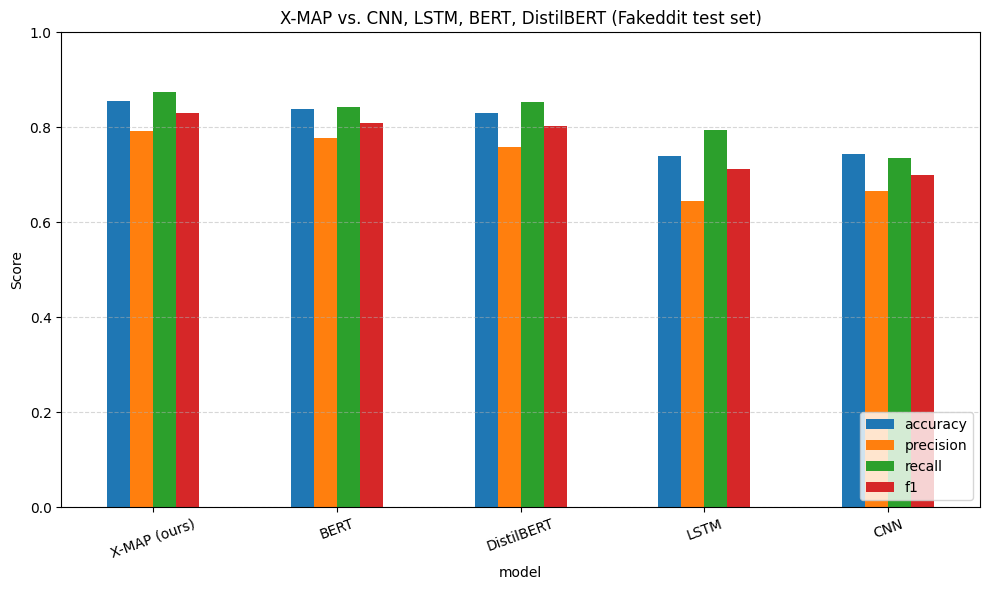

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind="bar", ax=ax, rot=20)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("X-MAP vs. CNN, LSTM, BERT, DistilBERT (Fakeddit test set)")
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("baseline_comparison_chart.png", dpi=150)
plt.show()


### Notes for the paper

- All baselines were trained on X-MAP's **duplicate-aware, group-wise split** (reproduced in cell 2 above via the same clustering + `StratifiedGroupKFold` procedure as the main notebook, `random_state=42`), not the original 70/10/20 random split, so this is now a fair, same-split comparison against X-MAP's actual reported (post-leakage-fix) results.
- CNN and LSTM use a from-scratch 128-d embedding trained only on this dataset (no pretrained word vectors); if your paper wants a stronger classical baseline, swap in pretrained GloVe/word2vec embeddings for the `nn.Embedding` layer.
- BERT and DistilBERT here are **text-only**, fine-tuned the same way (differential LR, partial layer freezing, class-weighted loss, early stopping on val F1) as X-MAP's own text branch, so the gap between DistilBERT (text-only) and X-MAP (text+image) isolates the contribution of the image modality and fusion.
- `NUM_EPOCHS=3` mirrors X-MAP's training budget for a fair compute comparison; increase it if you want each baseline pushed further.